# Galerkin approximation sanity check

This notebook compares coefficient vectors in $\mathbb{R}^m$ with their reconstructed functions in $V_m$ for the heat equation on $(0,\pi)$.

## 1. Galerkin basis and general parameters

We use the orthonormal Dirichlet eigenfunctions $w_j(x)=\sqrt{2/\pi}\sin(jx)$ and eigenvalues $\lambda_j=j^2$.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import scipy.optimize as optimize

pi = np.pi
m = 20

def w(j, x):
    return np.sqrt(2 / pi) * np.sin(j * x)

lambdas = np.arange(1, m + 1, dtype=float) ** 2

## 2. Reusable experimental functions

These factories make it easy to change the initial condition and impulse profile without changing the Galerkin code.

In [28]:
def rectangular_pulse(amplitude, left, right):
    def pulse(x):
        return amplitude * np.where((left <= x) & (x <= right), 1.0, 0.0)
    return pulse

def triangular_impulse(amplitude, center, half_width):
    if not (0 < center - half_width < center + half_width < pi):
        raise ValueError("The triangular impulse must be supported inside (0, pi).")

    def impulse(x):
        return amplitude * np.maximum(1.0 - np.abs(x - center) / half_width, 0.0)
    return impulse

def polynomial_bump(amplitude=1.0):
    def bump(x):
        return amplitude * x * (pi - x)
    return bump

def sine_mode(j, amplitude=1.0):
    def mode(x):
        return amplitude * w(j, x)
    return mode

## 3. Experiment setup

The quadrature breakpoints mark the jumps of the initial condition and the corners of the triangular impulse. The impulse is continuous, piecewise linear, and belongs to $H_0^1(0,\pi)$.

In [29]:
u0 = rectangular_pulse(
    amplitude=4.0,
    left=pi / 3,
    right=2 * pi / 3,
)
u0_points = [pi / 3, 2 * pi / 3]

A = 1.5
x0 = pi / 2
r = pi / 3
b = triangular_impulse(amplitude=A, center=x0, half_width=r)
b_points = [x0 - r, x0, x0 + r]

## 4. $L^2$ projection

Because the basis is orthonormal, the projection coefficients are simply $(f,w_j)_{L^2(0,\pi)}$.

In [30]:
def inner(f, g, points=None):
    value, error = integrate.quad(
        lambda x: f(x) * g(x),
        0,
        pi,
        points=points,
    )
    return value

def project_coeffs(f, points=None):
    return np.array([
        inner(f, lambda x, j=j: w(j, x), points=points)
        for j in range(1, m + 1)
    ])

c0 = project_coeffs(u0, points=u0_points)
beta = project_coeffs(b, points=b_points)

print("c0   =", c0)
print("beta =", beta)

c0   = [ 3.19153824e+00  3.84797758e-16 -2.12769216e+00 -3.55451314e-16
  6.38307649e-01 -1.43925426e-16  4.55934035e-01  2.65647319e-16
 -7.09230721e-01  5.30259122e-17  2.90139840e-01  3.04150934e-16
  2.45502942e-01  1.01997952e-16 -4.25538432e-01 -8.01834218e-17
  1.87737544e-01 -5.22124991e-18  1.67975697e-01 -6.05728857e-16]
beta = [ 1.14288545e+00  5.55111512e-17 -5.07949087e-01  0.00000000e+00
  4.57154179e-02  8.32667268e-17 -2.33241928e-02  5.55111512e-17
  5.64387875e-02  2.77555756e-17 -9.44533427e-03  6.24500451e-16
  6.76263578e-03  1.73472348e-16 -2.03179635e-02 -1.80411242e-16
  3.95462092e-03 -6.24500451e-17 -3.16588766e-03  2.49800181e-16]


## 5. Evolution and reconstruction

Each coefficient decays independently as $c_j(t)=c_j(0)e^{-\lambda_j t}$. Reconstruction maps the resulting vector back into $V_m$.

In [31]:
def evolve_c(c_initial, t):
    return c_initial * np.exp(-lambdas * t)

def reconstruct_u(c, x_grid):
    basis_values = np.array([w(j, x_grid) for j in range(1, m + 1)])
    return c @ basis_values

### Impulse function and its Galerkin projection

The exact spatial impulse $b(x)$ is shown together with the projected impulse $P_m b$ used in the coefficient update.

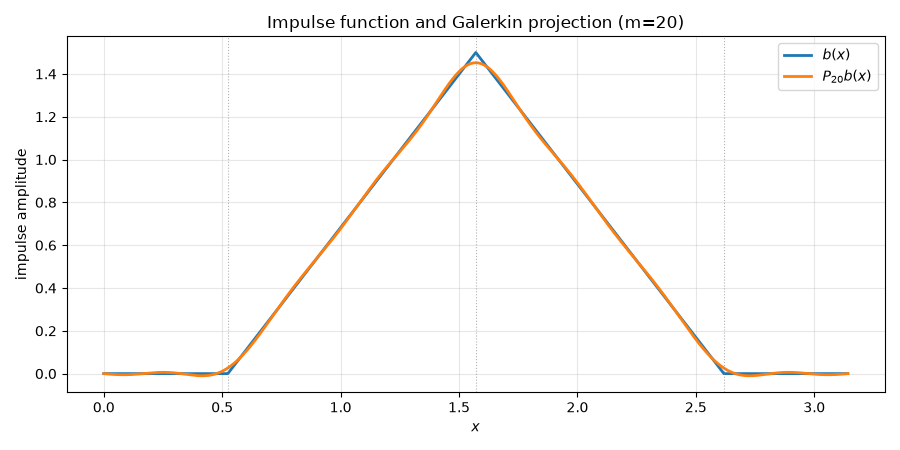

In [32]:
x_grid = np.linspace(0, pi, 2001)
b_values = b(x_grid)
Pm_b_values = reconstruct_u(beta, x_grid)

plt.figure(figsize=(9, 4.5))
plt.plot(x_grid, b_values, label=r"$b(x)$", linewidth=2)
plt.plot(x_grid, Pm_b_values, label=rf"$P_{{{m}}}b(x)$", linewidth=2)
for point in b_points:
    plt.axvline(point, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
plt.xlabel(r"$x$")
plt.ylabel("impulse amplitude")
plt.title(f"Impulse function and Galerkin projection (m={m})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Initial condition and its Galerkin projection

With only five modes, the projection smooths the jumps and shows the expected oscillation near the discontinuities.

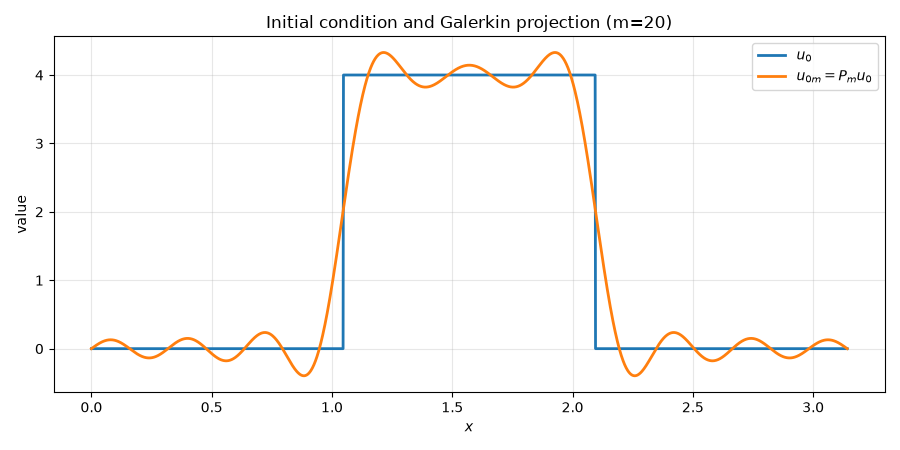

In [33]:
x_grid = np.linspace(0, pi, 2001)
u0_values = u0(x_grid)
u0m_values = reconstruct_u(c0, x_grid)

plt.figure(figsize=(9, 4.5))
plt.plot(x_grid, u0_values, label=r"$u_0$", linewidth=2)
plt.plot(x_grid, u0m_values, label=r"$u_{0m}=P_m u_0$", linewidth=2)
plt.xlabel(r"$x$")
plt.ylabel("value")
plt.title(f"Initial condition and Galerkin projection (m={m})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Check $\tau(c(t))=\|u_m(t)\|_{L^2}^2$

Orthonormality identifies the squared Euclidean norm of the coefficients with the squared $L^2$ norm of the reconstructed function. The grid integral should agree up to discretization error.

In [34]:
def tau_c(c):
    return np.sum(c**2)

def tau_u_grid(u_values, x_grid):
    return np.trapezoid(u_values**2, x_grid)

test_times = [0.0, 0.1, 0.5, 1.0]
for t in test_times:
    c_t = evolve_c(c0, t)
    u_t = reconstruct_u(c_t, x_grid)
    tau_coeffs = tau_c(c_t)
    tau_function = tau_u_grid(u_t, x_grid)
    print(
        f"t={t:>4.1f}: tau(c)={tau_coeffs:.12f}, "
        f"||u_m||_L2^2={tau_function:.12f}, "
        f"error={abs(tau_coeffs - tau_function):.3e}"
    )

t= 0.0: tau(c)=16.220308007206, ||u_m||_L2^2=16.220308007206, error=0.000e+00
t= 0.1: tau(c)=9.090600119111, ||u_m||_L2^2=9.090600119111, error=0.000e+00
t= 0.5: tau(c)=3.747747902870, ||u_m||_L2^2=3.747747902870, error=0.000e+00
t= 1.0: tau(c)=1.378513944266, ||u_m||_L2^2=1.378513944266, error=2.220e-16


## 8. Check the impulse equivalence

We compare reconstruction after the coefficient update $c^+=c^-+\beta$ with direct addition of $P_m b$ in function space.

In [35]:
t_minus = 0.4
c_minus = evolve_c(c0, t_minus)
c_plus = c_minus + beta

u_minus = reconstruct_u(c_minus, x_grid)
Pm_b = reconstruct_u(beta, x_grid)
u_plus_direct = u_minus + Pm_b
u_plus_from_coeffs = reconstruct_u(c_plus, x_grid)

max_error = np.max(np.abs(u_plus_from_coeffs - u_plus_direct))
print(f"Maximum impulse-equivalence error: {max_error:.3e}")

Maximum impulse-equivalence error: 8.882e-16


## 9. First impulse time

For $F(t)=t-\tau(c(t))$, a sign change on $[0,T]$ guarantees a root that `optimize.brentq` can find. We check the endpoints first so failure is explicit.

In [36]:
T = 2.0

def F_first(t):
    return t - tau_c(evolve_c(c0, t))

F_left = F_first(0.0)
F_right = F_first(T)

if F_left == 0.0:
    theta1 = 0.0
elif F_right == 0.0:
    theta1 = T
elif F_left * F_right < 0.0:
    theta1 = optimize.brentq(F_first, 0.0, T)
else:
    raise ValueError(
        f"No first impulse time found on [0, {T}]: "
        f"F(0)={F_left:.6g} and F(T)={F_right:.6g} have the same sign."
    )

print(f"theta_1 = {theta1:.12f}")
print(f"F(theta_1) = {F_first(theta1):.3e}")

theta_1 = 1.108843998108
F(theta_1) = -2.220e-16


## 10. Piecewise evolution with multiple impulses

Starting from each post-impulse state, the simulator evolves the coefficients analytically until the next root of $t-\tau(c(t))=0$, records the left limit $c^-$, and applies $c^+=c^-+\beta$. Time in the trigger is absolute time.

In [37]:
def simulate_impulsive_system(
    c_initial, beta, T_final, tau_function=tau_c, max_impulses=1000
):
    segments = []
    impulses = []
    t_start = 0.0
    c_start = np.array(c_initial, dtype=float, copy=True)

    while t_start < T_final:
        def c_on_segment(t):
            return evolve_c(c_start, t - t_start)

        def trigger(t):
            return t - tau_function(c_on_segment(t))

        F_start = trigger(t_start)
        F_end = trigger(T_final)

        # F is strictly increasing between impulses. A future root exists
        # exactly when it is negative now and nonnegative at T_final.
        if F_start < 0.0 and F_end >= 0.0:
            theta = optimize.brentq(trigger, t_start, T_final)
            c_minus = c_on_segment(theta)
            c_plus = c_minus + beta

            segments.append({
                "start": t_start,
                "end": theta,
                "c_start": c_start.copy(),
            })
            impulses.append({
                "time": theta,
                "c_minus": c_minus,
                "c_plus": c_plus,
            })

            if len(impulses) >= max_impulses:
                raise RuntimeError(
                    "Maximum number of impulses reached; "
                    "increase max_impulses or check for accumulation."
                )

            t_start = theta
            c_start = c_plus
        else:
            segments.append({
                "start": t_start,
                "end": T_final,
                "c_start": c_start.copy(),
            })
            break

    return segments, impulses


def state_at_time(t, segments):
    if not segments or t < segments[0]["start"] or t > segments[-1]["end"]:
        raise ValueError("t is outside the simulated interval.")

    # Searching backward makes the state right-continuous: at an impulse
    # time the returned value is the post-impulse state c_plus.
    for segment in reversed(segments):
        if t >= segment["start"] - 1e-12:
            return evolve_c(segment["c_start"], t - segment["start"])

    raise RuntimeError("No trajectory segment contains this time.")

We simulate once with $\tau$ computed from coefficients and once from the reconstructed function. Matching event lists provide a direct numerical check that both representations produce the same impulse times.

In [38]:
T_final = 5.0

def tau_via_reconstruction(c):
    return tau_u_grid(reconstruct_u(c, x_grid), x_grid)

segments_c, impulses_c = simulate_impulsive_system(
    c0, beta, T_final, tau_function=tau_c
)
segments_u, impulses_u = simulate_impulsive_system(
    c0, beta, T_final, tau_function=tau_via_reconstruction
)

times_c = np.array([event["time"] for event in impulses_c])
times_u = np.array([event["time"] for event in impulses_u])

print(f"Number of impulses on [0, {T_final}]: {len(times_c)}")
for k, (theta_c, theta_u) in enumerate(zip(times_c, times_u), start=1):
    print(
        f"theta_{k}: coefficient={theta_c:.12f}, "
        f"function={theta_u:.12f}, difference={abs(theta_c-theta_u):.3e}"
    )

if len(times_c) != len(times_u):
    raise AssertionError("The two representations found different event counts.")

impulse_time_error = (
    np.max(np.abs(times_c - times_u)) if len(times_c) else 0.0
)
print(f"Maximum impulse-time difference: {impulse_time_error:.3e}")

Number of impulses on [0, 5.0]: 9
theta_1: coefficient=1.108843998108, function=1.108843998108, difference=0.000e+00
theta_2: coefficient=1.646205414634, function=1.646205414634, difference=0.000e+00
theta_3: coefficient=2.149749493094, function=2.149749493094, difference=0.000e+00
theta_4: coefficient=2.626020843673, function=2.626020843673, difference=4.441e-16
theta_5: coefficient=3.080016557186, function=3.080016557186, difference=0.000e+00
theta_6: coefficient=3.515424513978, function=3.515424513978, difference=4.441e-16
theta_7: coefficient=3.935014512873, function=3.935014512873, difference=4.441e-16
theta_8: coefficient=4.340918444337, function=4.340918444337, difference=8.882e-16
theta_9: coefficient=4.734815904187, function=4.734815904187, difference=8.882e-16
Maximum impulse-time difference: 8.882e-16


## 11. Interactive trajectory

Move the Matplotlib slider to see the reconstructed state. The lower plot shows $\tau(c(t))$ together with the trigger line $t$; dashed vertical lines mark impulses. The \`ipympl\` backend keeps the figure interactive inside the notebook.

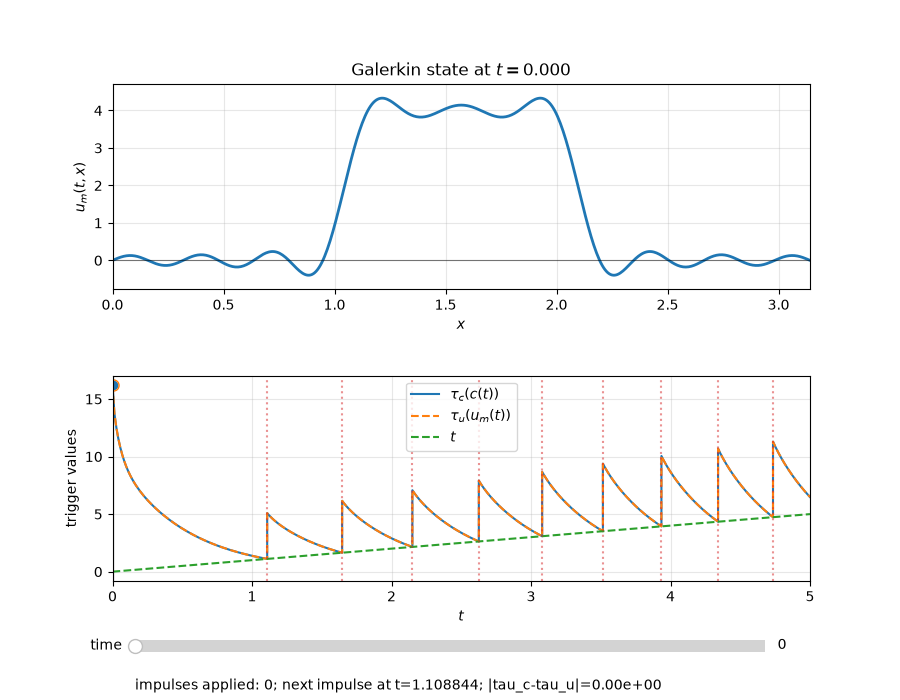

In [39]:
%matplotlib widget
from matplotlib.widgets import Slider

display_x = np.linspace(0.0, pi, 501)

# Sample each smooth segment separately. Repeated impulse times create
# vertical jumps from the left state to the right state in the tau plot.
trajectory_times = []
trajectory_coeffs = []
for segment in segments_c:
    local_times = np.linspace(segment["start"], segment["end"], 80)
    trajectory_times.extend(local_times)
    trajectory_coeffs.extend([
        evolve_c(segment["c_start"], t - segment["start"])
        for t in local_times
    ])

trajectory_times = np.asarray(trajectory_times)
trajectory_coeffs = np.asarray(trajectory_coeffs)
trajectory_tau = np.array([tau_c(c) for c in trajectory_coeffs])
trajectory_u = np.array([
    reconstruct_u(c, display_x) for c in trajectory_coeffs
])
trajectory_tau_u = np.array([
    tau_u_grid(u_values, display_x) for u_values in trajectory_u
])

fig, (ax_profile, ax_trigger) = plt.subplots(2, 1, figsize=(9, 7))
fig.subplots_adjust(bottom=0.17, hspace=0.42)

initial_c = state_at_time(0.0, segments_c)
profile_line, = ax_profile.plot(
    display_x,
    reconstruct_u(initial_c, display_x),
    linewidth=2,
)
ax_profile.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax_profile.set_xlim(0.0, pi)
u_min = min(0.0, np.min(trajectory_u))
u_max = max(0.0, np.max(trajectory_u))
u_padding = 0.08 * (u_max - u_min or 1.0)
ax_profile.set_ylim(u_min - u_padding, u_max + u_padding)
ax_profile.set_xlabel(r"$x$")
ax_profile.set_ylabel(r"$u_m(t,x)$")
ax_profile.set_title(r"Galerkin state at $t=0.000$")
ax_profile.grid(alpha=0.3)

ax_trigger.plot(
    trajectory_times,
    trajectory_tau,
    label=r"$\tau_c(c(t))$",
)
ax_trigger.plot(
    trajectory_times,
    trajectory_tau_u,
    "--",
    label=r"$\tau_u(u_m(t))$",
)
ax_trigger.plot(
    [0.0, T_final],
    [0.0, T_final],
    "--",
    label=r"$t$",
)
for theta in times_c:
    ax_trigger.axvline(
        theta,
        color="tab:red",
        linestyle=":",
        alpha=0.5,
    )
time_cursor = ax_trigger.axvline(
    0.0,
    color="black",
    linewidth=1.5,
)
tau_marker, = ax_trigger.plot(
    [0.0],
    [tau_c(initial_c)],
    "o",
    color="tab:blue",
)
initial_u = reconstruct_u(initial_c, display_x)
tau_u_marker, = ax_trigger.plot(
    [0.0],
    [tau_u_grid(initial_u, display_x)],
    "o",
    color="tab:orange",
    markerfacecolor="none",
    markersize=8,
)
ax_trigger.set_xlim(0.0, T_final)
ax_trigger.set_xlabel(r"$t$")
ax_trigger.set_ylabel("trigger values")
ax_trigger.grid(alpha=0.3)
ax_trigger.legend()

slider_axis = fig.add_axes([0.15, 0.06, 0.70, 0.035])
time_slider = Slider(
    ax=slider_axis,
    label="time",
    valmin=0.0,
    valmax=T_final,
    valinit=0.0,
)
status_text = fig.text(0.15, 0.015, "impulses applied: 0")

def update_time(t):
    t = float(t)
    c_t = state_at_time(t, segments_c)
    u_t = reconstruct_u(c_t, display_x)
    tau_c_t = tau_c(c_t)
    tau_u_t = tau_u_grid(u_t, display_x)
    profile_line.set_ydata(u_t)
    ax_profile.set_title(rf"Galerkin state at $t={t:.3f}$")
    time_cursor.set_xdata([t, t])
    tau_marker.set_data([t], [tau_c_t])
    tau_u_marker.set_data([t], [tau_u_t])

    impulse_count = np.searchsorted(times_c, t, side="right")
    if impulse_count < len(times_c):
        message = (
            f"impulses applied: {impulse_count}; "
            f"next impulse at t={times_c[impulse_count]:.6f}; "
            f"|tau_c-tau_u|={abs(tau_c_t-tau_u_t):.2e}"
        )
    else:
        message = (
            f"impulses applied: {impulse_count}; "
            f"no later impulse on [0, {T_final}]; "
            f"|tau_c-tau_u|={abs(tau_c_t-tau_u_t):.2e}"
        )
    status_text.set_text(message)
    fig.canvas.draw_idle()

time_slider.on_changed(update_time)
update_time(0.0)
plt.show()

## Conclusion

The numerical checks confirm the coordinate/function correspondence, preservation of the norm formula under reconstruction, equivalence of the coefficient and projected-function impulse updates, and equality of all detected impulse times in both representations.